Milan Chavarria
Trevor Henderson
https://archive.ics.uci.edu/dataset/222/bank+marketing

In [29]:
#import pandas, numphy, plt, and sns
#Step 1: upload libraries
import numpy as np                          # Common alias: np
import pandas as pd                         # Common alias: pd
import matplotlib.pyplot as plt             # Common alias: plt
import seaborn as sns                       # Common alias: sns

In [30]:
get_ipython().system('pip install ucimlrepo')
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [31]:
df = pd.concat([X, y], axis=1)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [32]:
# STEP 3: EXPLORE THE DATA
#feature engineering the data to identify missing values. First i will use df.info() to identify missing values.

print(df.info())

missing_values_count = df.isnull().sum()
missing_values_percentage = 100 * df.isnull().sum() / len(df)

missing_values_df = pd.DataFrame({
    'Missing Count': missing_values_count,
    'Missing Percentage': missing_values_percentage
})

missing_values_df = missing_values_df[missing_values_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if not missing_values_df.empty:
    print("\nColumns with Missing Values:")
    print(missing_values_df)
else:
    print("\nNo missing values found in the DataFrame.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None

Columns with Missing Values:
           Missing Count  

In [33]:
#Drop the missing values with high missing percentages, in 'education' and 'job' and input the missing values
education_mode = df['education'].mode()[0]
df['education'] = df['education'].fillna(education_mode)

job_mode = df['job'].mode()[0]
df['job'] = df['job'].fillna(job_mode)

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
age                0
job                0
marital            0
education          0
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64


In [34]:
#Target which features will have one hot encoding applied.  I need to identify categorical features, apply One-Hot Encoding, and then apply Label Encoding to the target variable 'y'.
categorical_cols = df.select_dtypes(include='object').columns.tolist()
# Exclude the target column 'y' from one-hot encoding
if 'y' in categorical_cols:
    categorical_cols.remove('y')

# Apply One-Hot Encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Apply Label Encoding to the target column 'y'
pd.set_option('future.no_silent_downcasting', True)
df['y'] = df['y'].replace({'yes': 1, 'no': 0})

print("DataFrame after encoding:")
print(df.head())

DataFrame after encoding:
   age  balance  day_of_week  duration  campaign  pdays  previous  y  \
0   58     2143            5       261         1     -1         0  0   
1   44       29            5       151         1     -1         0  0   
2   33        2            5        76         1     -1         0  0   
3   47     1506            5        92         1     -1         0  0   
4   33        1            5       198         1     -1         0  0   

   job_blue-collar  job_entrepreneur  ...  month_jan  month_jul  month_jun  \
0            False             False  ...      False      False      False   
1            False             False  ...      False      False      False   
2            False              True  ...      False      False      False   
3             True             False  ...      False      False      False   
4             True             False  ...      False      False      False   

   month_mar  month_may  month_nov  month_oct  month_sep  poutcome_other

In [35]:
#Columns 'poutcome' and 'contact' were dropped due to a high percentage of missing values
#Missing values in education and job were impute
#The target variable y was label encoded, mapping yes to 1 and no to 0

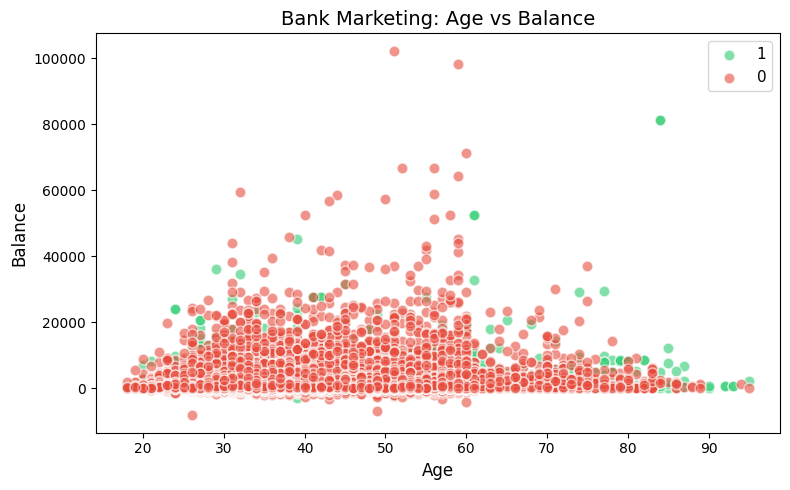

   -> Scatter plot saved as 'bank_marketing_scatter.png'
   -> Look to see whether customers who subscribed ('1')
      appear separated from those who did not ('0').
      If there is some visible grouping, KNN may perform well.



In [36]:
import matplotlib.pyplot as plt             # Common alias: plt
plt.figure(figsize=(8, 5))  # Set the figure size (width=8, height=5 inches)

import matplotlib.pyplot as plt

# Define colors for each outcome using the label-encoded values (0 and 1)
colors = {1: '#2ecc71', 0: '#e74c3c'}

# Loop through each outcome and plot its points
for outcome, color in colors.items():
    # Filter the dataframe to only include this outcome
    subset = df[df['y'] == outcome]

    # Plot scatter plot
    plt.scatter(
        subset['age'],          # x-axis values
        subset['balance'],      # y-axis values
        c=color,                # dot color
        label=outcome,          # legend label
        alpha=0.6,              # transparency
        edgecolors='w',         # white border around each dot
        s=60                    # dot size
    )

# Add labels and title
plt.xlabel('Age', fontsize=12)
plt.ylabel('Balance', fontsize=12)
plt.title('Bank Marketing: Age vs Balance', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('bank_marketing_scatter.png', dpi=150)
plt.show()

print("   -> Scatter plot saved as 'bank_marketing_scatter.png'")
print("   -> Look to see whether customers who subscribed ('1')")
print("      appear separated from those who did not ('0').")
print("      If there is some visible grouping, KNN may perform well.")
print()

In [37]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# Data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# Concatenate X and y into a single DataFrame 'df'
df = pd.concat([X, y], axis=1)

In [38]:
# Handle missing values for 'education' and 'job'
education_mode = df['education'].mode()[0]
df['education'] = df['education'].fillna(education_mode)

job_mode = df['job'].mode()[0]
df['job'] = df['job'].fillna(job_mode)

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
age                0
job                0
marital            0
education          0
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64


In [39]:
# ============================================================================
# STEP 4: PREPARE THE DATA FOR MACHINE LEARNING
# ============================================================================
# Before we can train a model, we need to:
#   A) Separate features (X) from labels (y)
#   B) Split into training set and testing set
#   C) Scale the features
print("STEP 4: Preparing the Data")
print("-" * 40)
#
# ============================================================================
# Target which features will have one-hot encoding applied.
categorical_cols = df.select_dtypes(include='object').columns.tolist()
# Exclude the target column 'y' from one-hot encoding
if 'y' in categorical_cols:
    categorical_cols.remove('y')

# Apply One-Hot Encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Apply Label Encoding to the target column 'y'
pd.set_option('future.no_silent_downcasting', True)
df['y'] = df['y'].replace({'yes': 1, 'no': 0})

print("DataFrame after encoding:")
print(df.head())

STEP 4: Preparing the Data
----------------------------------------
DataFrame after encoding:
   age  balance  day_of_week  duration  campaign  pdays  previous  y  \
0   58     2143            5       261         1     -1         0  0   
1   44       29            5       151         1     -1         0  0   
2   33        2            5        76         1     -1         0  0   
3   47     1506            5        92         1     -1         0  0   
4   33        1            5       198         1     -1         0  0   

   job_blue-collar  job_entrepreneur  ...  month_jan  month_jul  month_jun  \
0            False             False  ...      False      False      False   
1            False             False  ...      False      False      False   
2            False              True  ...      False      False      False   
3             True             False  ...      False      False      False   
4             True             False  ...      False      False      False   

   m

In [40]:
# --- A) Separate features from labels ---
# X = all input columns except 'y'
# y = the labels we want to predict (the 'y' column)

X = df.drop('y', axis=1)
y = df['y']

print(f"Features (X) shape: {X.shape}")
print(f"Labels (y) shape:   {y.shape}")
print()

Features (X) shape: (45211, 38)
Labels (y) shape:   (45211,)



In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [42]:
# --- B) Split into training and testing sets ---
# test_size=0.2 means 20% of data goes to testing, 80% to training
# random_state=42 makes the split reproducible
# stratify=y ensures both sets have the same proportion of each class
#   (e.g., if 10% of customers subscribed, both training AND testing
#    sets will keep that same proportion)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # Reproducibility
    stratify=y           # Keep class proportions balanced (yes/no)
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print()

Training samples: 36168
Testing samples:  9043



In [43]:
# --- C) Scale the features ---
# WHY SCALE?
#   KNN uses DISTANCE to find neighbors. If one feature (like Area)
#   ranges from 40,000 to 85,000, and another (like Roundness) ranges
#   from 0.65 to 0.95, then Area would COMPLETELY dominate the
#   distance calculation. Roundness would barely matter at all!
#
#   StandardScaler transforms each feature so it has:
#     - mean = 0  (centered at zero)
#     - standard deviation = 1  (same spread)
#
# IMPORTANT DISTINCTION:
#   fit_transform() on TRAINING data = learn the mean & std, then scale
#   transform()     on TESTING data  = use the SAME mean & std from training
#
#   Why? If we used fit_transform on test data too, we'd be using
#   information from the test set during training. This is called
#   "DATA LEAKAGE" and it gives artificially inflated accuracy.

scaler = StandardScaler()

# Learn mean & std from training data, then scale it
X_train_scaled = scaler.fit_transform(X_train)

# Scale test data using the SAME mean & std (no new fitting!)
X_test_scaled = scaler.transform(X_test)

print("Features have been scaled using StandardScaler.")
print("   -> Training data: fit_transform (learn + scale)")
print("   -> Testing data:  transform only (scale using same parameters)")
print()



Features have been scaled using StandardScaler.
   -> Training data: fit_transform (learn + scale)
   -> Testing data:  transform only (scale using same parameters)



In [44]:
# Encoding (VERY important for bank dataset)
X = pd.get_dummies(X, drop_first=True)

# Scaling (VERY important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
print("Target column preview:")
print(y.head())
print()

print("Target dtype:")
print(y.dtype)
print()

print("Unique target values:")
print(y.unique())
print()

Target column preview:
0    0
1    0
2    0
3    0
4    0
Name: y, dtype: object

Target dtype:
object

Unique target values:
[0 1]



In [48]:
y = y.astype(int)

In [49]:
# Separate features and labels
X = df.drop('y', axis=1)
y = df['y']

# FIX: Convert target to numeric (VERY IMPORTANT)
y = y.astype(int)

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

In [53]:
# Separate features and target
X = df.drop(columns=['y'])
y = df['y'].copy()

# Force target into clean 1-dimensional integer labels
y = pd.to_numeric(y, errors='coerce')
y = y.dropna().astype(int)

# Keep X matched to y after dropping any bad rows
X = X.loc[y.index]

# Encode categorical feature columns
X = pd.get_dummies(X, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Make absolutely sure y is 1D integer labels
y_train = pd.Series(y_train).astype(int)
y_test = pd.Series(y_test).astype(int)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("y_train dtype:", y_train.dtype)
print("y_train unique values:", y_train.unique())

X_train shape: (36168, 38)
y_train shape: (36168,)
y_train dtype: int64
y_train unique values: [0 1]


In [54]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [55]:
# ============================================================================
# STEP 5: BUILD AND TRAIN THE KNN MODEL
# ============================================================================
# In this step, we train a K-Nearest Neighbors (KNN) model to predict
# whether a customer will subscribe to a term deposit (yes/no).
#
# n_neighbors=5 means the model looks at the 5 most similar customers
# and uses their outcomes to make a prediction.
# ============================================================================

print("STEP 5: Training the KNN Model")
print("-" * 40)

# Create the KNN model with K = 5 neighbors
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model using the scaled training data
# KNN stores all training data and compares new customers to it
knn.fit(X_train_scaled, y_train)

print("Model trained using 5 nearest neighbors.")
print()

# Make predictions on the test set
# For each customer in the test set:
#   1. Calculate distance to all training customers
#   2. Identify the 5 closest (most similar)
#   3. Use majority voting (yes/no) to predict outcome
y_pred = knn.predict(X_test_scaled)

print("Predictions made for the test dataset.")
print()

STEP 5: Training the KNN Model
----------------------------------------
Model trained using 5 nearest neighbors.

Predictions made for the test dataset.



STEP 6: Evaluating the Model
----------------------------------------
Overall Accuracy: 89.28%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7985
           1       0.58      0.31      0.41      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.64      0.67      9043
weighted avg       0.87      0.89      0.88      9043




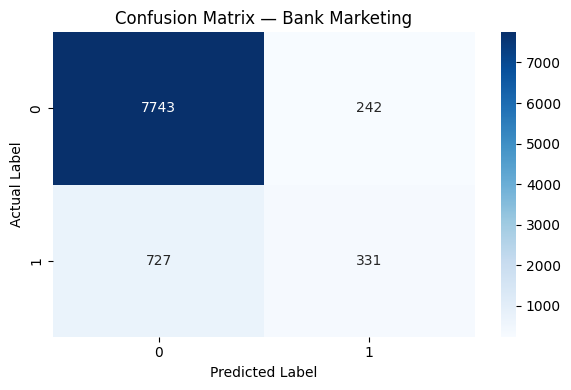

   -> Confusion matrix saved as 'bank_confusion.png'



In [56]:
# ============================================================================
# STEP 6: EVALUATE THE MODEL
# ============================================================================
# How good is our model? Let's measure it several ways:
#
#   Accuracy:    What % of predictions were correct?
#   Precision:   When we predicted a class, how often were we right?
#   Recall:      Of all actual members of a class, how many did we find?
#   F1-Score:    A balanced combination of precision and recall
#
# We also create a CONFUSION MATRIX — a table showing:
#   - Rows    = actual values
#   - Columns = predicted values
#   - Diagonal cells = correct predictions
#   - Off-diagonal cells = mistakes
# ============================================================================

print("STEP 6: Evaluating the Model")
print("-" * 40)

# --- Overall accuracy ---
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.2%}")
print()

# --- Detailed classification report ---
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))
#   precision = of all customers we predicted as 1, how many really were 1?
#   recall    = of all actual 1 customers, how many did we correctly identify?
#   f1-score  = balanced combination of precision and recall
#   support   = number of actual samples in each class
print()

# --- Confusion Matrix Heatmap ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0', '1'],
    yticklabels=['0', '1']
)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix — Bank Marketing')
plt.tight_layout()
plt.savefig('bank_confusion.png', dpi=150)
plt.show()

print("   -> Confusion matrix saved as 'bank_confusion.png'")
print()

STEP 7: Finding the Best K
----------------------------------------


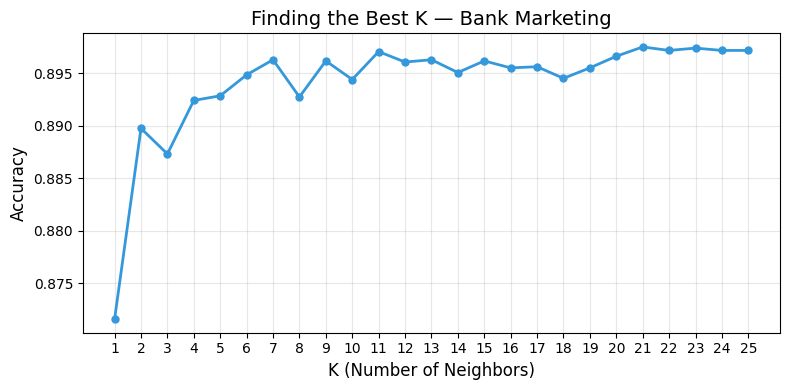

   -> Best K = 21
   -> Best Accuracy = 89.75%
   -> Chart saved as 'bank_best_k.png'



In [57]:
# ============================================================================
# STEP 7: FIND THE BEST VALUE OF K
# ============================================================================
# We used K=5 above, but is that the best choice?
# Let's test values from 1 to 25 and find which gives the highest accuracy
# for predicting whether a customer will subscribe (0 or 1).
# ============================================================================

print("STEP 7: Finding the Best K")
print("-" * 40)

# Test K values from 1 to 25
k_values = range(1, 26)
accuracies = []

for k in k_values:
    # Create model with current K
    model = KNeighborsClassifier(n_neighbors=k)

    # Train model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    pred = model.predict(X_test_scaled)

    # Store accuracy
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)

# Plot K vs Accuracy
plt.figure(figsize=(8, 4))
plt.plot(
    k_values,
    accuracies,
    marker='o',
    color='#3498db',
    linewidth=2,
    markersize=5
)

plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Finding the Best K — Bank Marketing', fontsize=14)
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('bank_best_k.png', dpi=150)
plt.show()

# Find best K
best_k = list(k_values)[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print(f"   -> Best K = {best_k}")
print(f"   -> Best Accuracy = {best_accuracy:.2%}")
print(f"   -> Chart saved as 'bank_best_k.png'")
print()

In [58]:
# ============================================================================
# STEP 8: MAKE A PREDICTION ON NEW DATA
# ============================================================================
# Now let's use our trained model to predict whether a new customer
# will subscribe to a term deposit (0 = No, 1 = Yes).
#
# IMPORTANT:
#   - We must encode the new data the SAME way as training data
#   - We must scale using the SAME scaler
# ============================================================================

print("STEP 8: Predicting for a New Customer")
print("-" * 40)

# Retrain model using best K
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)

# Example new customer (use values similar to your dataset)
new_customer = pd.DataFrame({
    'age': [35],
    'job': ['technician'],
    'marital': ['single'],
    'education': ['tertiary'],
    'default': ['no'],
    'balance': [2500],
    'housing': ['yes'],
    'loan': ['no'],
    'contact': ['cellular'],
    'day': [12],
    'month': ['may'],
    'duration': [180],
    'campaign': [2],
    'pdays': [999],
    'previous': [0],
    'poutcome': ['unknown']
})

print("New customer data:")
print(new_customer.to_string(index=False))
print()

# --- Encode new customer (same as training) ---
new_customer_encoded = pd.get_dummies(new_customer, drop_first=True)

# --- Match columns with training data ---
# This ensures missing columns are added and aligned correctly
new_customer_encoded = new_customer_encoded.reindex(columns=X.columns, fill_value=0)

# --- Scale using SAME scaler ---
new_customer_scaled = scaler.transform(new_customer_encoded)

# --- Make prediction ---
prediction = final_model.predict(new_customer_scaled)

# Convert 0/1 to readable output
label = "Yes (Will Subscribe)" if prediction[0] == 1 else "No (Will Not Subscribe)"
print(f"Predicted outcome: {label}")

# --- Probability scores ---
probabilities = final_model.predict_proba(new_customer_scaled)

print("Confidence scores:")
for class_name, prob in zip(final_model.classes_, probabilities[0]):
    bar = '█' * int(prob * 30)
    print(f"   Class {class_name}: {prob:6.1%}  {bar}")

print()
print("=" * 60)
print("   DONE! You've completed the Bank Marketing KNN model.")
print("=" * 60)

STEP 8: Predicting for a New Customer
----------------------------------------
New customer data:
 age        job marital education default  balance housing loan  contact  day month  duration  campaign  pdays  previous poutcome
  35 technician  single  tertiary      no     2500     yes   no cellular   12   may       180         2    999         0  unknown

Predicted outcome: No (Will Not Subscribe)
Confidence scores:
   Class 0:  57.1%  █████████████████
   Class 1:  42.9%  ████████████

   DONE! You've completed the Bank Marketing KNN model.
